
# CISC7204 Data Science and Data Visualization Project

# Macao Employment Earnings Analysis

## Dataset

Cleaned dataset:
**Macao_Employment_Earnings_Cleaned.xlsx**

The dataset contains:
- Quarterly employment earnings by industry
- Employment earnings trends over time
- Educational attainment related employment information

## Objectives

1. Analyze employment earnings changes in Macao.
2. Compare earnings among industries.
3. Visualize income differences and trends.
4. Explore changes before and after COVID-19.


In [1]:

# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12,5)

pd.set_option("display.max_columns", None)



## 1. Load Cleaned Dataset

Put:
Macao_Employment_Earnings_Cleaned.xlsx

in the same folder as this notebook.


In [2]:

file = "Macao_Employment_Earnings_Cleaned.xlsx"

industry = pd.read_excel(
    file,
    sheet_name="Industry_Earnings"
)

education = pd.read_excel(
    file,
    sheet_name="Education_Attainment"
)

industry.head()


,Period,Date,Manufacturing,Electricity_gas_water_supply,Construction,Wholesale_retail_trade,Hotels_restaurants_similar,Transport_storage_communications,Financial_activities,Real_estate_business_activities,Public_administration_social_security,Education,Health_social_welfare,Recreational_cultural_gaming_other_services,Full_time_resident_employee_median_income
0,1st Quarter/2014,2014-03-01,10400.0,20000.0,13000.0,12000.0,11000.0,13000.0,20000.0,10000.0,27500.0,20000.0,18000.0,17000.0,16000.0
1,2nd Quarter/2014,2014-06-01,10000.0,20000.0,13000.0,12000.0,11000.0,13000.0,18000.0,10000.0,28600.0,20000.0,15000.0,16000.0,15000.0
2,3rd Quarter/2014,2014-09-01,10000.0,20000.0,15000.0,12000.0,12000.0,13600.0,17000.0,11000.0,34000.0,21000.0,16300.0,17000.0,16000.0
3,4th Quarter/2014,2014-12-01,11000.0,26000.0,14000.0,12000.0,12000.0,13000.0,15500.0,10500.0,34700.0,20000.0,19000.0,17500.0,16500.0
4,1st Quarter/2015,2015-03-01,14000.0,35000.0,15000.0,14000.0,13000.0,14800.0,20000.0,12300.0,31600.0,23000.0,20000.0,19000.0,18000.0



## 2. Dataset Overview


In [3]:

print("Industry dataset:")
print(industry.shape)

industry.info()

print("\nEducation dataset:")
print(education.shape)

education.head()


Industry dataset:
(49, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 15 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Period                                       48 non-null     object        
 1   Date                                         44 non-null     datetime64[ns]
 2   Manufacturing                                44 non-null     float64       
 3   Electricity_gas_water_supply                 40 non-null     float64       
 4   Construction                                 44 non-null     float64       
 5   Wholesale_retail_trade                       44 non-null     float64       
 6   Hotels_restaurants_similar                   44 non-null     float64       
 7   Transport_storage_communications             44 non-null     float64       
 8   Financial_activities                         44 non-nul

,Period,Date,Junior_secondary_education,Senior_secondary_education,Tertiary_education,Others
0,1st Quarter/2014,2014-03-01,63.9,79.0,80.9,8.6
1,2nd Quarter/2014,2014-06-01,65.9,77.3,82.3,8.8
2,3rd Quarter/2014,2014-09-01,62.8,77.2,88.5,9.0
3,4th Quarter/2014,2014-12-01,64.5,75.1,93.5,9.4
4,1st Quarter/2015,2015-03-01,65.0,73.4,95.1,9.1



# Visualization 1

## Overall Employment Earnings Trend

This visualization shows how employment earnings changed over time.


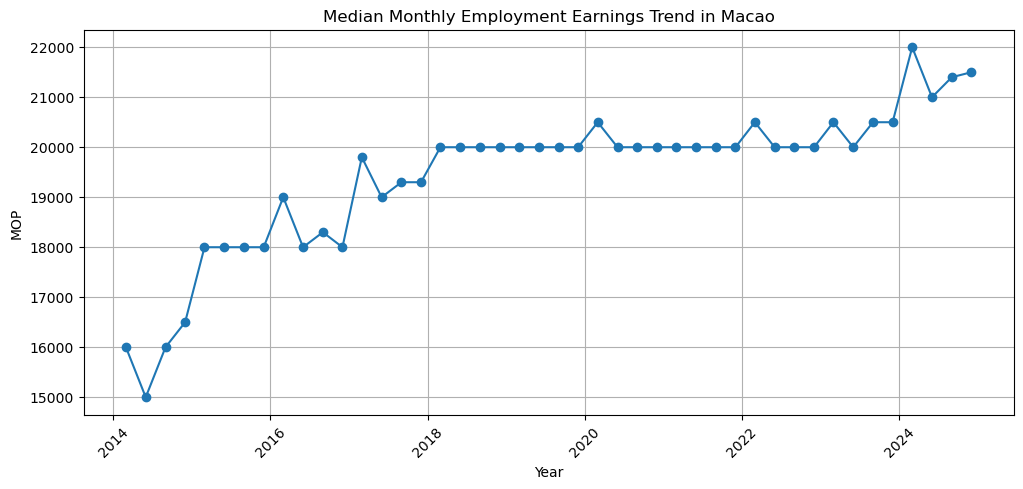

In [4]:

plt.figure(figsize=(12,5))

plt.plot(
    industry["Date"],
    industry["Full_time_resident_employee_median_income"],
    marker="o"
)

plt.title(
    "Median Monthly Employment Earnings Trend in Macao"
)

plt.xlabel("Year")
plt.ylabel("MOP")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()



# Visualization 2

## Average Earnings by Industry

Compare average earnings among industries.


In [5]:

industry_columns = [
    c for c in industry.columns
    if c not in [
        "Period",
        "Date",
        "Full_time_resident_employee_median_income"
    ]
]

avg_income = pd.DataFrame({
    "Industry": industry_columns,
    "Average Income": [
        industry[c].mean()
        for c in industry_columns
    ]
})

avg_income = avg_income.sort_values(
    "Average Income",
    ascending=False
)

avg_income


,Industry,Average Income
8,Public_administration_social_security,40854.545455
1,Electricity_gas_water_supply,25252.500000
9,Education,25136.363636
10,Health_social_welfare,23561.363636
6,Financial_activities,20093.181818
11,Recreational_cultural_gaming_other_services,19381.818182
2,Construction,16370.454545
5,Transport_storage_communications,15706.818182
4,Hotels_restaurants_similar,14543.181818
3,Wholesale_retail_trade,14131.818182


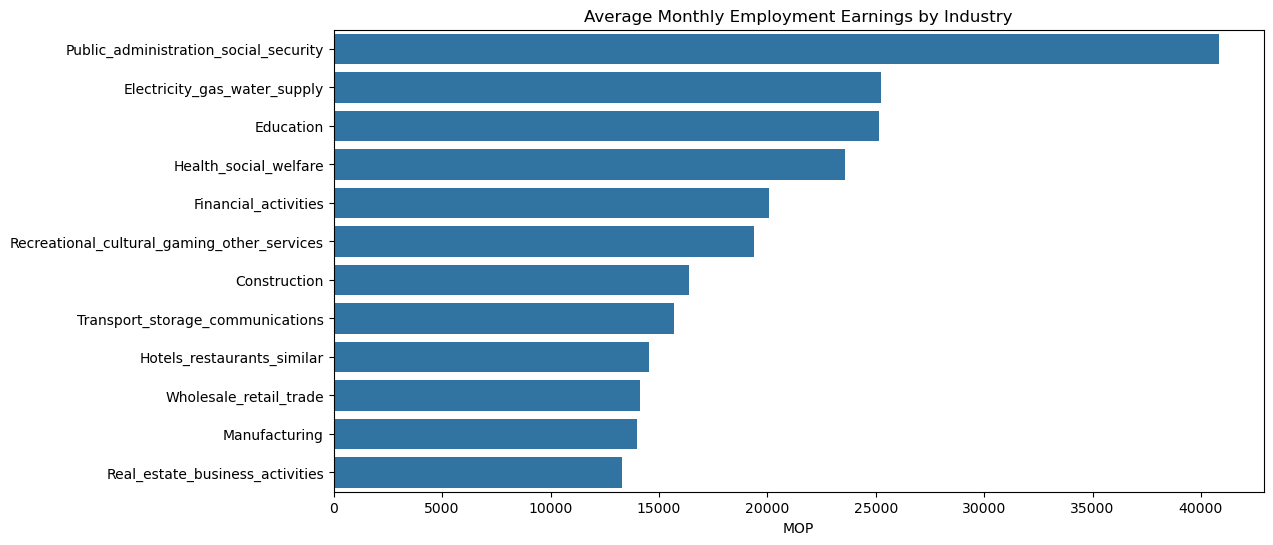

In [6]:

plt.figure(figsize=(12,6))

sns.barplot(
    data=avg_income,
    x="Average Income",
    y="Industry"
)

plt.title(
    "Average Monthly Employment Earnings by Industry"
)

plt.xlabel("MOP")
plt.ylabel("")

plt.show()



# Visualization 3

## Industry Earnings Trend Comparison


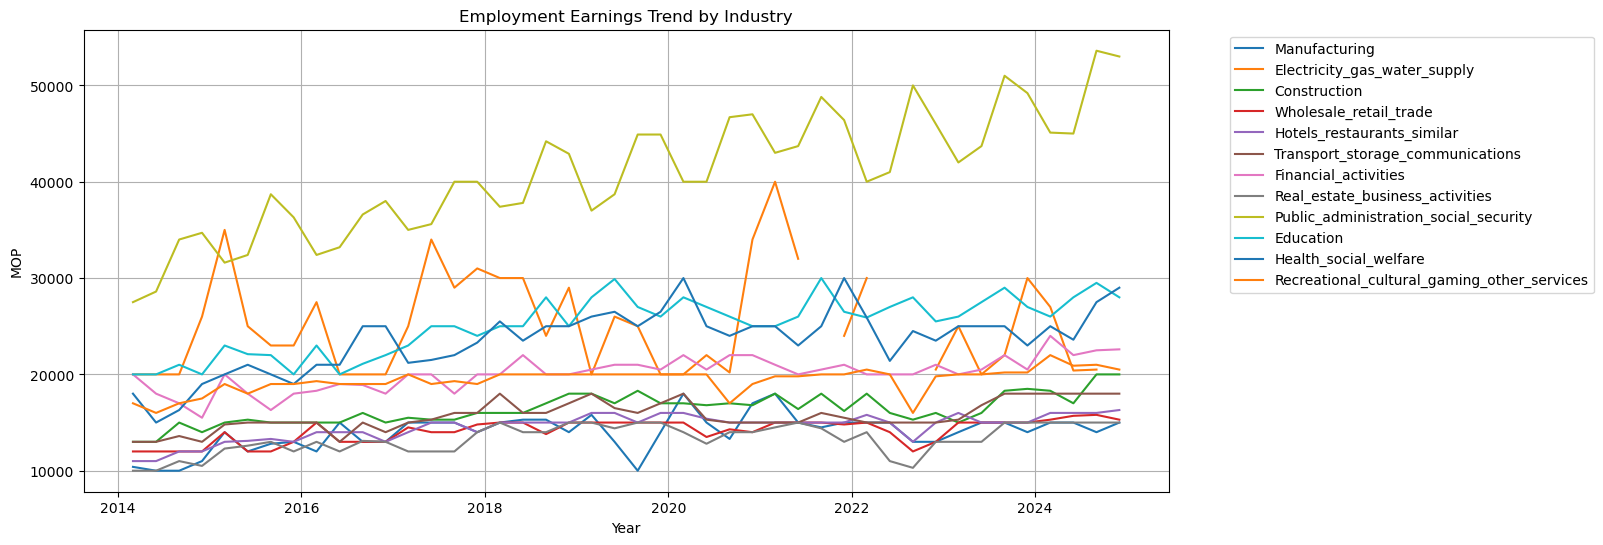

In [7]:

plt.figure(figsize=(14,6))

for col in industry_columns:
    plt.plot(
        industry["Date"],
        industry[col],
        label=col
    )

plt.title(
    "Employment Earnings Trend by Industry"
)

plt.xlabel("Year")
plt.ylabel("MOP")

plt.legend(
    bbox_to_anchor=(1.05,1)
)

plt.grid(True)

plt.show()



# Visualization 4

## Industry Earnings Heatmap

Shows income patterns across industries and time.


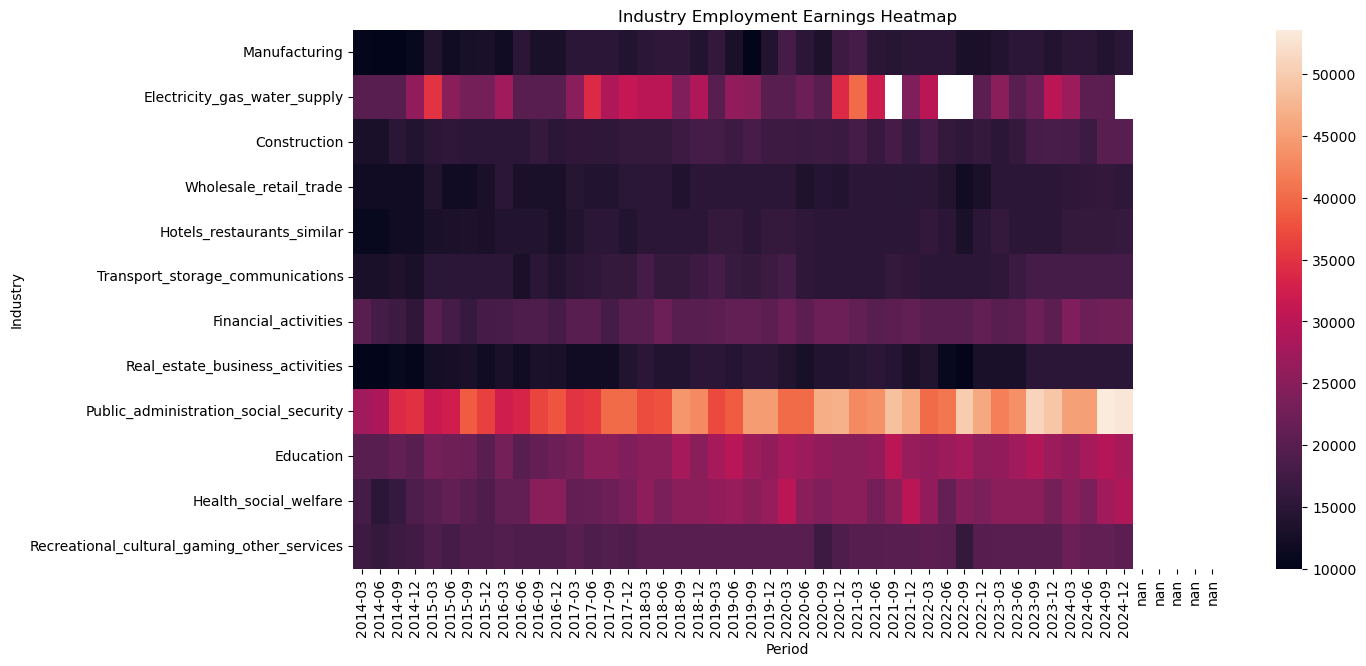

In [8]:

heatmap_data = industry[industry_columns].T

heatmap_data.columns = (
    industry["Date"]
    .dt.strftime("%Y-%m")
)

plt.figure(figsize=(14,7))

sns.heatmap(
    heatmap_data
)

plt.title(
    "Industry Employment Earnings Heatmap"
)

plt.xlabel("Period")
plt.ylabel("Industry")

plt.show()



# Visualization 5

## Educational Attainment Employment Trend

Use the education sheet to observe employment structure changes.


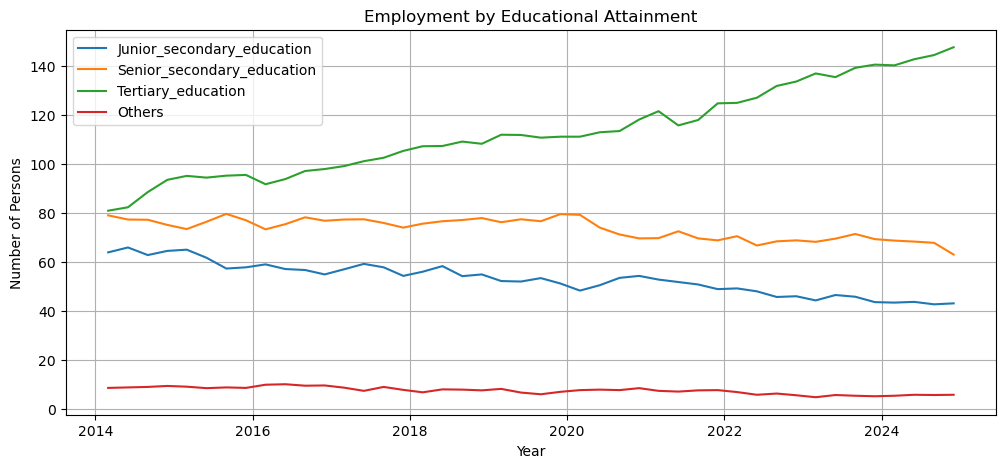

In [9]:

education_columns = [
    c for c in education.columns
    if c not in ["Period","Date"]
]

plt.figure(figsize=(12,5))

for col in education_columns:
    plt.plot(
        education["Date"],
        education[col],
        label=col
    )

plt.title(
    "Employment by Educational Attainment"
)

plt.xlabel("Year")
plt.ylabel("Number of Persons")

plt.legend()

plt.grid(True)

plt.show()



# Conclusion

Discuss:

1. Overall earnings growth trend.
2. Differences between industries.
3. Changes in employment structure.
4. Possible impact of COVID-19.

Limitations:
- The analysis focuses on available DSEC indicators.
- Further integration with additional economic datasets can improve conclusions.
